# Overview
This project analyzes transactional data from an online gift store that ships products by mail and serves both wholesale and retail customers. The goal is to demonstrate an end-to-end data analysis workflow in Python: from data preparation and exploratory analysis to customer segmentation and statistical hypothesis testing.

# Исследование интернет-магазина «Подарочек»

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px
from scipy.stats import ttest_ind
from scipy.stats import ttest_rel
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import mannwhitneyu

In [2]:
row_main = pd.read_csv("gift (1).csv")
row_text = pd.read_csv("gift_entry (2).csv", sep=";")

In [3]:
import os
os.listdir()

['gift_entry (2).csv', 'project.ipynb', '.ipynb_checkpoints', 'gift (1).csv']

In [4]:
#row_main = pd.read_csv('/datasets/gift.csv') 

#url = "https://code.s3.yandex.net/python-for-analytics/gift_entry.csv"
#ow_text = pd.read_csv(url, sep=";") 

In [5]:
print(row_main.head())

         entry_date  order_id  customer_id  quantity  price  name_clust  \
0  12/01/2018 08:26      3031         2150         6    339         740   
1  12/01/2018 08:26      3031         2150         8    275         132   
2  12/01/2018 08:26      3031         2150         6    339         197   
3  12/01/2018 08:26      3031         2150         2    765         767   
4  12/01/2018 08:26      3031         2150         6    425         383   

   entry_id  country_id  
0       891          28  
1      1596          28  
2       166          28  
3      1810          28  
4      2585          28  


In [6]:
print(row_text.head())

   entry_id                                        entry
0         0                                          NaN
1         1                    10-цветная ручка Spaceboy
2         2                        12 карандашей, черепа
3         3  12 карандашей, высокий тюбик, лесной массив
4         4     12 карандашей, маленький тюбик с черепом


In [7]:
print(row_main.info)

<bound method DataFrame.info of               entry_date  order_id  customer_id  quantity  price  name_clust  \
0       12/01/2018 08:26      3031         2150         6    339         740   
1       12/01/2018 08:26      3031         2150         8    275         132   
2       12/01/2018 08:26      3031         2150         6    339         197   
3       12/01/2018 08:26      3031         2150         2    765         767   
4       12/01/2018 08:26      3031         2150         6    425         383   
...                  ...       ...          ...       ...    ...         ...   
356935  12/09/2019 12:50     48253         7320        12     85         556   
356936  12/09/2019 12:50     48253         7320         6    210         144   
356937  12/09/2019 12:50     48253         7320         4    415         144   
356938  12/09/2019 12:50     48253         7320         4    415         114   
356939  12/09/2019 12:50     48253         7320         3    495         785   

       

In [8]:
print(row_text.info)

<bound method DataFrame.info of       entry_id                                          entry
0            0                                            NaN
1            1                      10-цветная ручка Spaceboy
2            2                          12 карандашей, черепа
3            3    12 карандашей, высокий тюбик, лесной массив
4            4       12 карандашей, маленький тюбик с черепом
...        ...                                            ...
2912      2912  яйцо с подвесным украшением из слоновой кости
2913      2913      янтарное массивное колье из стекла+бусины
2914      2914                            яркие голубые ленты
2915      2915              ящик для хранения большой, черепа
2916      2916            ящик для хранения маленький, черепа

[2917 rows x 2 columns]>


In [9]:
print(row_main.isna().sum())

entry_date     0
order_id       0
customer_id    0
quantity       0
price          0
name_clust     0
entry_id       0
country_id     0
dtype: int64


In [10]:
print(row_main.duplicated().sum())

3573


In [11]:
row_main = row_main.drop_duplicates()

In [12]:
print(row_main['entry_date'].dtype)

object


In [13]:
row_main['entry_date'] = pd.to_datetime(row_main['entry_date'], format="%d/%m/%Y %H:%M")

In [14]:
print(row_text.isna().sum())

entry_id    0
entry       1
dtype: int64


In [15]:
row_text.dropna()

,entry_id,entry
1,1,10-цветная ручка Spaceboy
2,2,"12 карандашей, черепа"
3,3,"12 карандашей, высокий тюбик, лесной массив"
4,4,"12 карандашей, маленький тюбик с черепом"
5,5,12 колышков-ромашек в деревянной коробке.
...,...,...
2912,2912,яйцо с подвесным украшением из слоновой кости
2913,2913,янтарное массивное колье из стекла+бусины
2914,2914,яркие голубые ленты
2915,2915,"ящик для хранения большой, черепа"


In [16]:
print(row_text.duplicated().sum())

0


In [17]:
row_text = row_text.rename(columns={"entry": "goods"})

In [18]:
df = pd.merge(row_main, row_text, on="entry_id", how="left")
print(df)

                entry_date  order_id  customer_id  quantity  price  \
0      2018-01-12 08:26:00      3031         2150         6    339   
1      2018-01-12 08:26:00      3031         2150         8    275   
2      2018-01-12 08:26:00      3031         2150         6    339   
3      2018-01-12 08:26:00      3031         2150         2    765   
4      2018-01-12 08:26:00      3031         2150         6    425   
...                    ...       ...          ...       ...    ...   
353362 2019-09-12 12:50:00     48253         7320        12     85   
353363 2019-09-12 12:50:00     48253         7320         6    210   
353364 2019-09-12 12:50:00     48253         7320         4    415   
353365 2019-09-12 12:50:00     48253         7320         4    415   
353366 2019-09-12 12:50:00     48253         7320         3    495   

        name_clust  entry_id  country_id  \
0              740       891          28   
1              132      1596          28   
2              197       16

При очистке данных потерян 1% строк в главном датафрейме и всего одна строка в текстовом, что не затрудняет дальнейший анализ и свидетельствует о хорошем сборе информации. 

Data cleaning resulted in the removal of about 1% of rows from the main dataset and only one row from the text dataset, which does not impact the analysis and indicates good data quality.

# 2 Предобработка и начало исследовательского анализа

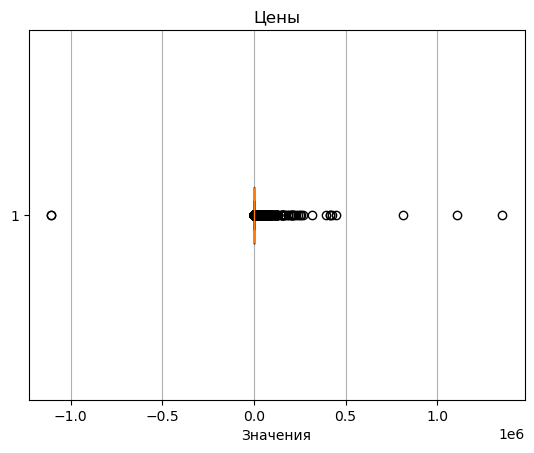

In [19]:
plt.boxplot(df["price"], vert=False)
plt.title("Цены")
plt.xlabel("Значения")
plt.grid(True, axis="x")
plt.show()

In [20]:
df = df[df['price'] >= 0]

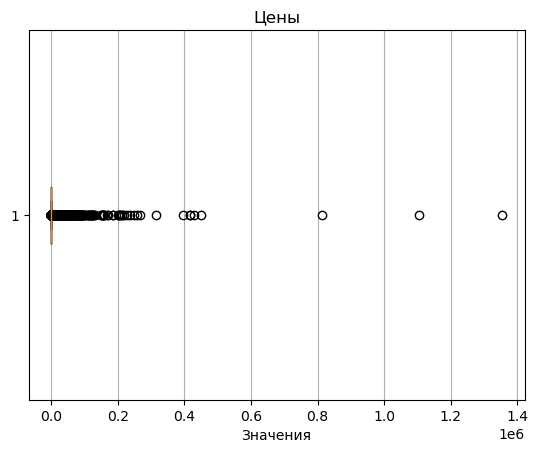

In [21]:
plt.boxplot(df["price"], vert=False)
plt.title("Цены")
plt.xlabel("Значения")
plt.grid(True, axis="x")
plt.show()

In [22]:
q95 = df['price'].quantile(0.95)
print(q95)

995.0


In [23]:
df = df[df['price'] <= q95]

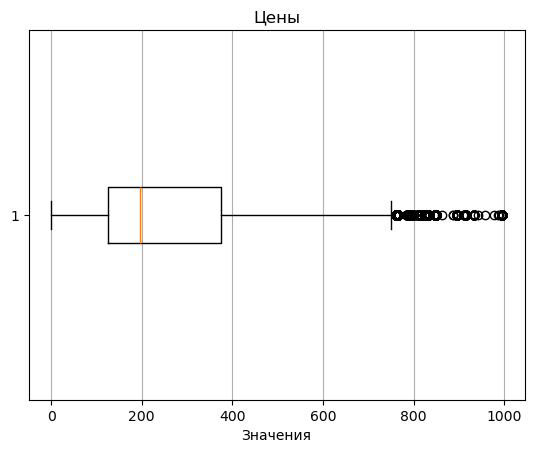

In [24]:
plt.boxplot(df["price"], vert=False)
plt.title("Цены")
plt.xlabel("Значения")
plt.grid(True, axis="x")
plt.show()

In [25]:
print(df['quantity'].mean())

10.588706611864769


In [26]:
print(df['quantity'].median())

4.0


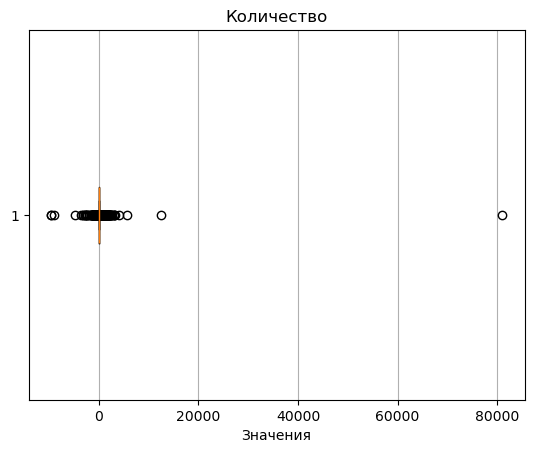

In [27]:
plt.boxplot(df["quantity"], vert=False)
plt.title("Количество")
plt.xlabel("Значения")
plt.grid(True, axis="x")
plt.show()

In [28]:
df = df[df['quantity'] >= 0]

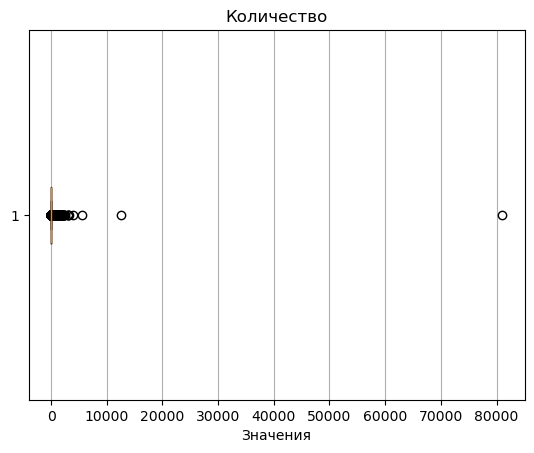

In [29]:
plt.boxplot(df["quantity"], vert=False)
plt.title("Количество")
plt.xlabel("Значения")
plt.grid(True, axis="x")
plt.show()

In [30]:
df = df[df['quantity'] <= q95]

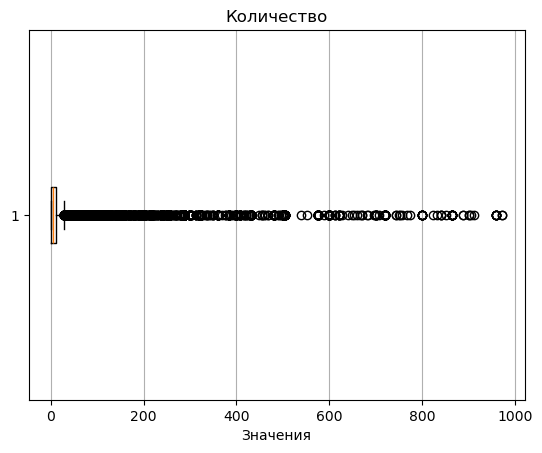

In [31]:
plt.boxplot(df["quantity"], vert=False)
plt.title("Количество")
plt.xlabel("Значения")
plt.grid(True, axis="x")
plt.show()

In [32]:
df['quantity'].describe()

count    335603.000000
mean         10.401748
std          29.404491
min           1.000000
25%           1.000000
50%           4.000000
75%          12.000000
max         972.000000
Name: quantity, dtype: float64

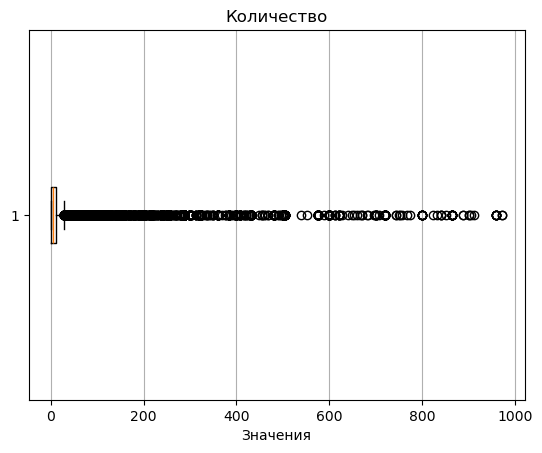

In [33]:
plt.boxplot(df["quantity"], vert=False)
plt.title("Количество")
plt.xlabel("Значения")
plt.grid(True, axis="x")
plt.show()

In [34]:
df["total_price"] = df["price"] * df["quantity"]

In [35]:
print(df.head())

           entry_date  order_id  customer_id  quantity  price  name_clust  \
0 2018-01-12 08:26:00      3031         2150         6    339         740   
1 2018-01-12 08:26:00      3031         2150         8    275         132   
2 2018-01-12 08:26:00      3031         2150         6    339         197   
3 2018-01-12 08:26:00      3031         2150         2    765         767   
4 2018-01-12 08:26:00      3031         2150         6    425         383   

   entry_id  country_id                                        goods  \
0       891          28                   белый металлический фонарь   
1      1596          28   кремовая вешалка в форме сердечек Купидона   
2       166          28                Вязаная грелка с флагом Союза   
3      1810          28             набор 7 скворечников для бабушек   
4      2585          28  стеклянный матовый держатель в форме звезды   

   total_price  
0         2034  
1         2200  
2         2034  
3         1530  
4         2550  


In [36]:
print(df['order_id'].describe())

count    335603.000000
mean      26722.881333
std       13357.684541
min        3031.000000
25%       14864.000000
50%       27438.000000
75%       38503.000000
max       48253.000000
Name: order_id, dtype: float64


In [37]:
print(df['customer_id'].describe())

count    335603.000000
mean       3545.714874
std        2516.687246
min          -1.000000
25%        1770.000000
50%        3721.000000
75%        5668.000000
max        7653.000000
Name: customer_id, dtype: float64


In [38]:
#df = df[df['customer_id'] > 0]

In [39]:
print(df['name_clust'].describe())

count    335603.00000
mean        474.97158
std         255.06113
min           0.00000
25%         256.00000
50%         453.00000
75%         704.00000
max         929.00000
Name: name_clust, dtype: float64


In [40]:
print(df['entry_id'].describe())

count    335603.000000
mean       1515.942429
std         829.758933
min           0.000000
25%         887.000000
50%        1549.000000
75%        2201.000000
max        2916.000000
Name: entry_id, dtype: float64


In [41]:
print(df['country_id'].describe())

count    335603.000000
mean         26.768283
std           4.944870
min           0.000000
25%          28.000000
50%          28.000000
75%          28.000000
max          29.000000
Name: country_id, dtype: float64


In [42]:
print(df.head())

           entry_date  order_id  customer_id  quantity  price  name_clust  \
0 2018-01-12 08:26:00      3031         2150         6    339         740   
1 2018-01-12 08:26:00      3031         2150         8    275         132   
2 2018-01-12 08:26:00      3031         2150         6    339         197   
3 2018-01-12 08:26:00      3031         2150         2    765         767   
4 2018-01-12 08:26:00      3031         2150         6    425         383   

   entry_id  country_id                                        goods  \
0       891          28                   белый металлический фонарь   
1      1596          28   кремовая вешалка в форме сердечек Купидона   
2       166          28                Вязаная грелка с флагом Союза   
3      1810          28             набор 7 скворечников для бабушек   
4      2585          28  стеклянный матовый держатель в форме звезды   

   total_price  
0         2034  
1         2200  
2         2034  
3         1530  
4         2550  


In [43]:

df["entry_date"] = pd.to_datetime(df["entry_date"])
daily = (
    df.groupby(df["entry_date"].dt.floor("D"))["quantity"]
      .sum()
      .rename_axis("date")
      .reset_index()
)

all_days = pd.DataFrame({
    "date": pd.date_range(daily["date"].min(), daily["date"].max(), freq="D")
})


calendar = all_days.merge(daily, on="date", how="left")
calendar["quantity"] = calendar["quantity"].fillna(0).astype(int)


calendar["month"] = calendar["date"].dt.to_period("M")

print(calendar)

          date  quantity    month
0   2018-01-12     16303  2018-01
1   2018-01-13         0  2018-01
2   2018-01-14         0  2018-01
3   2018-01-15         0  2018-01
4   2018-01-16         0  2018-01
..         ...       ...      ...
693 2019-12-06      5834  2019-12
694 2019-12-07      9436  2019-12
695 2019-12-08      7689  2019-12
696 2019-12-09     12310  2019-12
697 2019-12-10     11649  2019-12

[698 rows x 3 columns]


In [44]:
print(calendar.sort_values(by='month'))

          date  quantity    month
0   2018-01-12     16303  2018-01
19  2018-01-31         0  2018-01
18  2018-01-30         0  2018-01
17  2018-01-29         0  2018-01
15  2018-01-27         0  2018-01
..         ...       ...      ...
692 2019-12-05     26499  2019-12
693 2019-12-06      5834  2019-12
694 2019-12-07      9436  2019-12
695 2019-12-08      7689  2019-12
697 2019-12-10     11649  2019-12

[698 rows x 3 columns]


In [45]:
calendar["has_sales"] = calendar["quantity"] > 0


days_with_sales = (
    calendar.groupby("month")["has_sales"]
            .sum()
            .reset_index(name="days_with_sales")
)

print(days_with_sales)

      month  days_with_sales
0   2018-01                1
1   2018-02                1
2   2018-03                1
3   2018-04                0
4   2018-05                1
5   2018-06                1
6   2018-07                1
7   2018-08                1
8   2018-09                1
9   2018-10                1
10  2018-11                0
11  2018-12               11
12  2019-01               26
13  2019-02               22
14  2019-03               26
15  2019-04               22
16  2019-05               24
17  2019-06               27
18  2019-07               27
19  2019-08               25
20  2019-09               26
21  2019-10               26
22  2019-11               26
23  2019-12                8


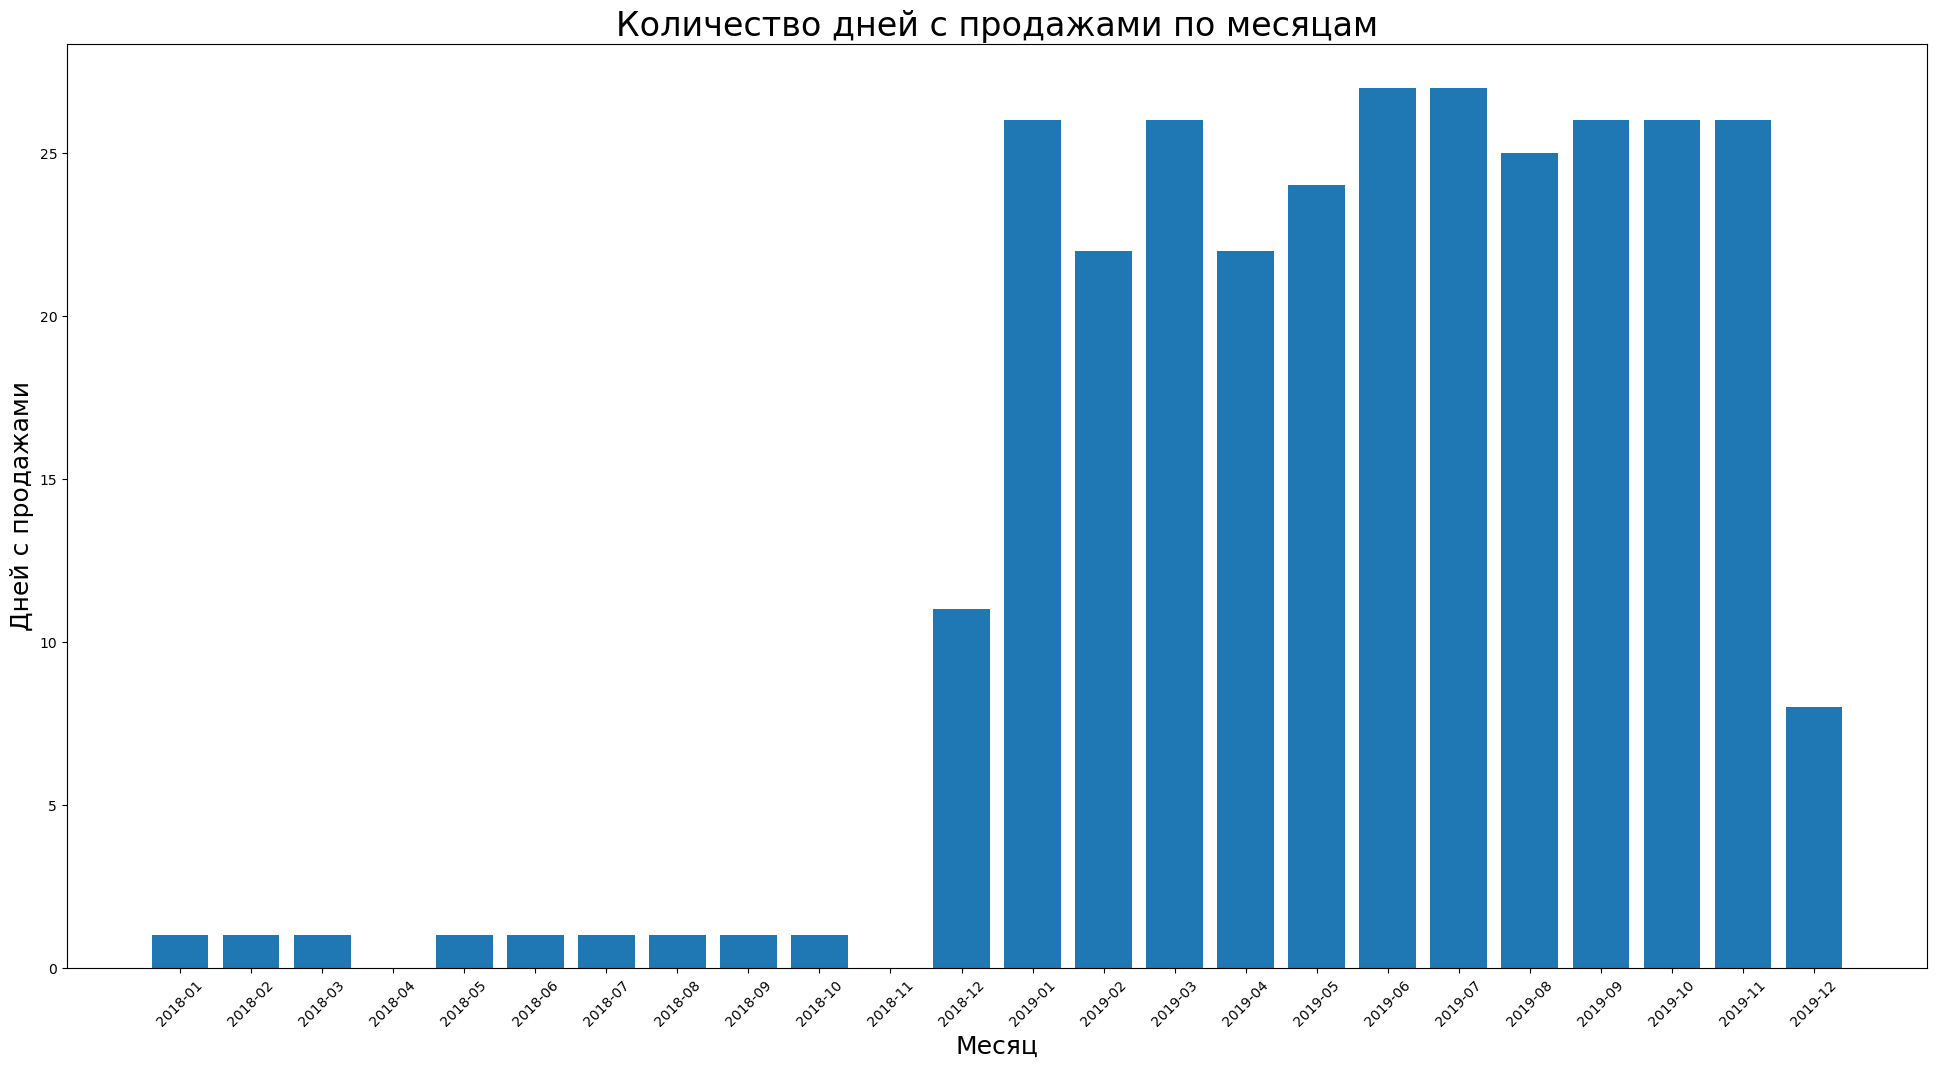

In [46]:
plt.figure(figsize=(24, 12))
plt.bar(days_with_sales["month"].astype(str), days_with_sales["days_with_sales"])
plt.title("Количество дней с продажами по месяцам", fontsize=24)
plt.xlabel("Месяц", fontsize=18)
plt.ylabel("Дней с продажами", fontsize=18)
plt.xticks(rotation=45)
plt.show()


In [47]:
df["entry_date"] = df["entry_date"].dt.strftime("%Y-%m-%d %H:%M:%S")

In [48]:
df = df[df["entry_date"] >= "2019-01-01 00:00:00"]

In [49]:
print(df.reset_index())

         index           entry_date  order_id  customer_id  quantity  price  \
0        26987  2019-04-01 10:00:00      6659         6687        10    195   
1        26988  2019-04-01 10:00:00      6659         6687         5    210   
2        26989  2019-04-01 10:00:00      6659         6687        10    125   
3        26990  2019-04-01 10:00:00      6659         6687        10    195   
4        26991  2019-04-01 10:00:00      6659         6687         6    295   
...        ...                  ...       ...          ...       ...    ...   
310277  353362  2019-09-12 12:50:00     48253         7320        12     85   
310278  353363  2019-09-12 12:50:00     48253         7320         6    210   
310279  353364  2019-09-12 12:50:00     48253         7320         4    415   
310280  353365  2019-09-12 12:50:00     48253         7320         4    415   
310281  353366  2019-09-12 12:50:00     48253         7320         3    495   

        name_clust  entry_id  country_id  \
0      

В ходе предобработки утраченно примерно 13% данных, оставшиеся 310282 строк отображают бизнес активность магазина, которую видно на графике по месяцам, с января 2019 по декабрь 2019 год включительно. 

During preprocessing, approximately 13% of the data was lost. The remaining 310,282 rows reflect the store’s business activity, as shown in the monthly timeline from January 2019 through December 2019.

# 3 Расчёт метрик

In [50]:
df["entry_date"] = pd.to_datetime(df["entry_date"])
df["hour"] = df["entry_date"].dt.hour             
df["weekday"] = df["entry_date"].dt.dayofweek + 1
weekday_labels = ["Пн","Вт","Ср","Чт","Пт","Сб","Вс"]

In [51]:
orders_by_weekday = (
    df.groupby("weekday")["order_id"].count()
      .reset_index()
      .rename(columns={"order_id": "num_orders"})
    .set_index("weekday").reindex(range(1,8), fill_value=0).reset_index()
)

In [52]:
users_by_weekday = (
    df.groupby("weekday")["customer_id"].nunique()
      .reset_index()
      .rename(columns={"customer_id": "unique_customers"})
    .set_index("weekday").reindex(range(1,8), fill_value=0).reset_index()
)

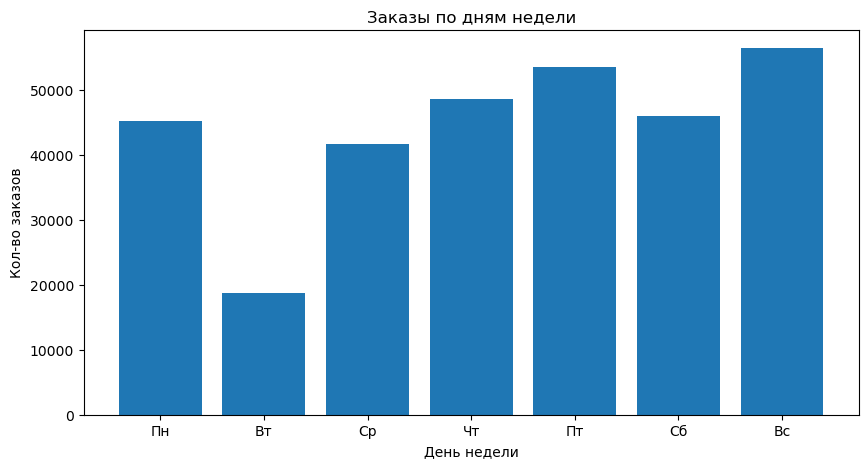

In [53]:
plt.figure(figsize=(10, 5))
plt.bar(orders_by_weekday["weekday"], orders_by_weekday["num_orders"])
plt.title("Заказы по дням недели")
plt.xlabel("День недели")
plt.ylabel("Кол-во заказов")
plt.xticks(range(1,8), weekday_labels)
plt.show()

Недельный барплот заказов демонстрирует флактуальность с упадком продаж меньше 20 тысяч во вторник и возрастанием к своему максимуму в пятницу и воскресенье. 

The weekly bar plot of orders shows noticeable fluctuations, with sales dropping below 20,000 on Tuesdays and increasing to a peak on Fridays and Sundays.

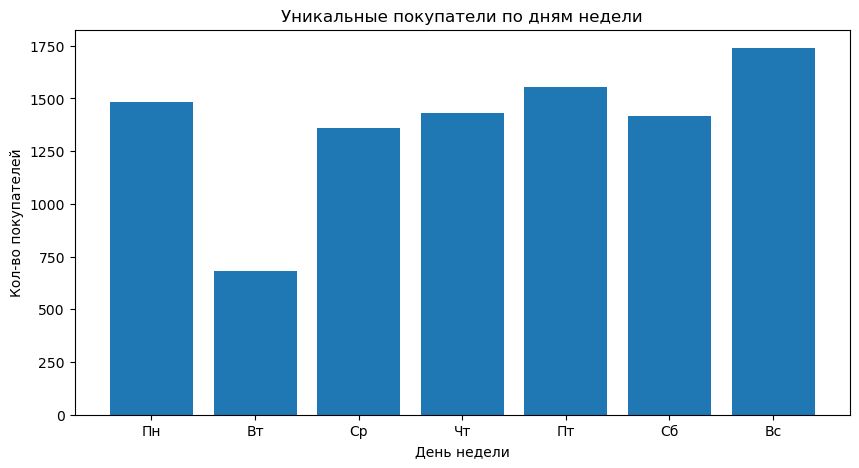

In [54]:
plt.figure(figsize=(10, 5))
plt.bar(users_by_weekday["weekday"], users_by_weekday["unique_customers"])
plt.title("Уникальные покупатели по дням недели")
plt.xlabel("День недели")
plt.ylabel("Кол-во покупателей")
plt.xticks(range(1,8), weekday_labels)
plt.show()

Количество покупателей как и количество заказов снижается до своего минимума во вторник и возрастает до 1750 в воскресенье. Вовлеченность в понедельник и пятницу сохраняется на уровне 1500 человек. 

Both the number of customers and the number of orders decline to their lowest point on Tuesday and increase to around 1,750 on Sunday. Customer engagement on Monday and Friday remains stable at approximately 1,500 users.

In [55]:
orders_by_hour = (
    df.groupby("hour")["order_id"].count()
      .reset_index()
      .rename(columns={"order_id": "num_orders"})
    .set_index("hour").reindex(range(24), fill_value=0).reset_index()
)

In [56]:
users_by_hour = (
    df.groupby("hour")["customer_id"].nunique()
      .reset_index()
      .rename(columns={"customer_id": "unique_customers"})
    .set_index("hour").reindex(range(24), fill_value=0).reset_index()
)

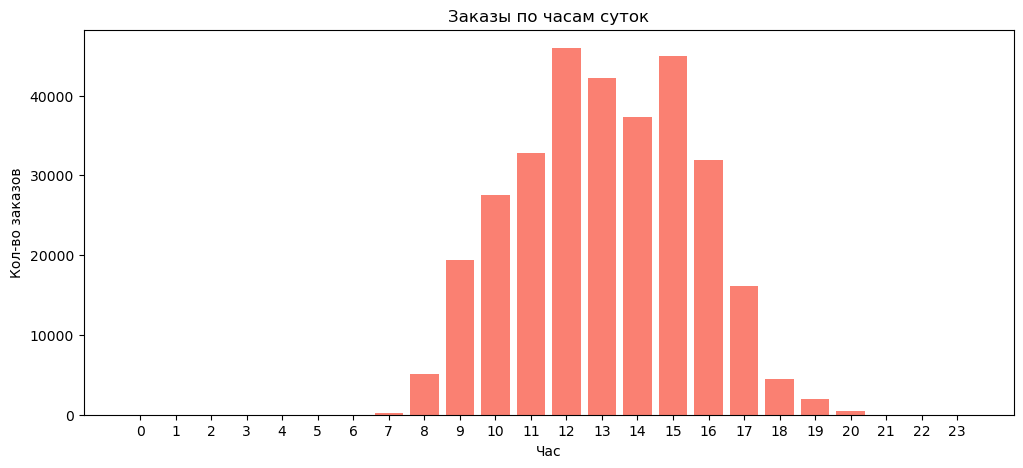

In [57]:
plt.figure(figsize=(12, 5))
plt.bar(orders_by_hour["hour"], orders_by_hour["num_orders"], color="salmon")
plt.title("Заказы по часам суток")
plt.xlabel("Час")
plt.ylabel("Кол-во заказов")
plt.xticks(range(24))
plt.show()

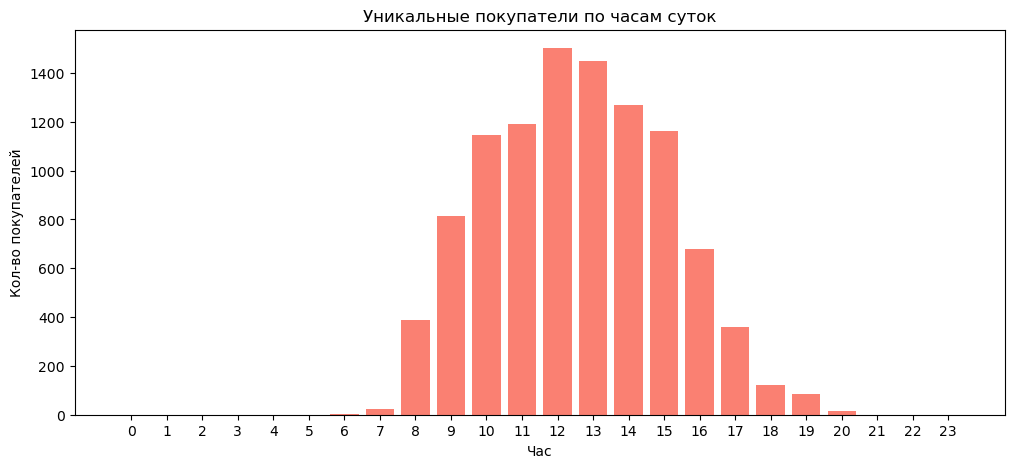

In [58]:
plt.figure(figsize=(12, 5))
plt.bar(users_by_hour["hour"], users_by_hour["unique_customers"], color="salmon")
plt.title("Уникальные покупатели по часам суток")
plt.xlabel("Час")
plt.ylabel("Кол-во покупателей")
plt.xticks(range(24))
plt.show()

Суточный график поведения покупателей показывает, что люди склонны делать покупки в рабочее время с 7 утра и до 8 вечера. Максимум заказов и покупателей в рабочее время в 12:00 с последующем снижением к 20:00.  

The daily customer behavior plot shows that users tend to make purchases during working hours, from 7 a.m. to 8 p.m. The highest number of orders and customers occurs around 12:00, followed by a gradual decline toward 8 p.m.

<div class="alert alert-danger">
<b>❌ Комментарий ревьюера v3:</b> 
<br>Графики и расчеты верные, но не хватает выводов
</div>

<div class="alert alert-success">
<b>✔️ Комментарий ревьюера v4:</b>
<br>Правка выполнена 👍
</div>

In [59]:
df["date"] = df["entry_date"].dt.floor("D")
df["month"] = df["entry_date"].dt.to_period("M")

In [60]:
daily_client_revenue = (
    df.groupby(["date", "customer_id"])["total_price"]
      .sum()
      .reset_index()
)

In [61]:
avg_rev_per_client = (
    daily_client_revenue.groupby(daily_client_revenue["date"].dt.to_period("M"))["total_price"]
                        .mean()
                        .reset_index(name="avg_revenue_per_client_per_day")
)

In [62]:
unique_clients = (
    df.groupby("month")["customer_id"]
      .nunique()
      .reset_index(name="unique_customers")
)

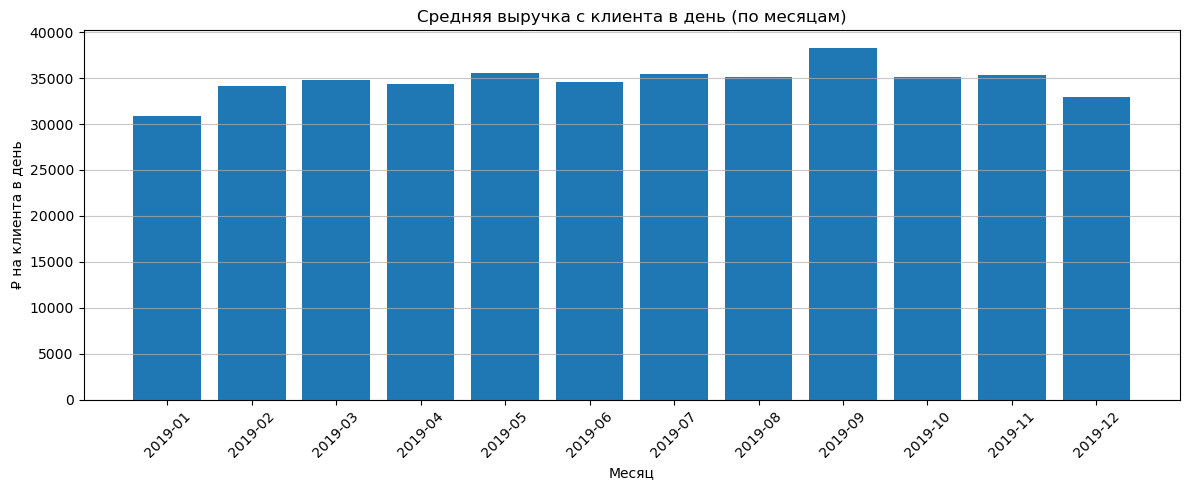

In [63]:
avg_rev_per_client_plot = avg_rev_per_client.sort_values("date") 
plt.figure(figsize=(12, 5))
plt.bar(
    avg_rev_per_client_plot["date"].astype(str),
    avg_rev_per_client_plot["avg_revenue_per_client_per_day"]
)
plt.title("Средняя выручка с клиента в день (по месяцам)")
plt.xlabel("Месяц")
plt.ylabel("₽ на клиента в день")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis="y", alpha=0.7)
plt.show()

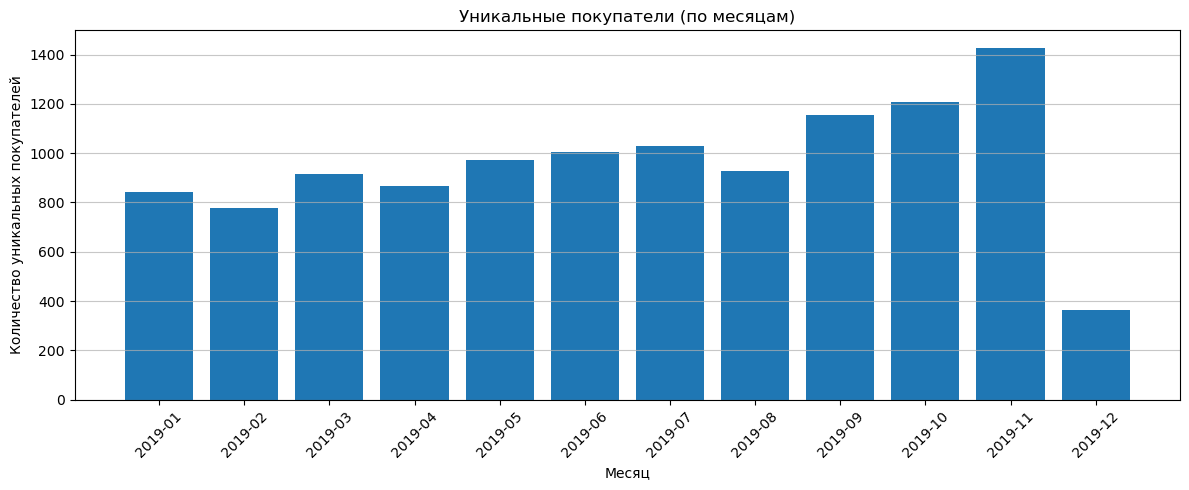

In [64]:
unique_clients_plot = unique_clients.sort_values("month")  
plt.figure(figsize=(12, 5))
plt.bar(
    unique_clients_plot["month"].astype(str),
    unique_clients_plot["unique_customers"]
)
plt.title("Уникальные покупатели (по месяцам)")
plt.xlabel("Месяц")
plt.ylabel("Количество уникальных покупателей")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis="y", alpha=0.7)
plt.show()

Средняя выручка с клиента в день с января по декабрь 2019 года остается практически неизменной около 35тысяч рублей, с незначительным снижением в январе и декабре и ростом в октябре. 

Средняя численность покупателей колеблется от 800 до 1000 человек с января по август, с последующим ростом к октябрю до более 1400 покупателей в день. В декабре количество людей резко снижается до менее 400 человек. 

The average daily revenue per customer from January to December 2019 remains largely stable at around 35,000 RUB, with a slight decrease in January and December and a noticeable increase in October.

The average number of customers fluctuates between 800 and 1,000 from January through August, followed by growth toward October, reaching more than 1,400 customers per day. In December, the number of customers drops sharply to fewer than 400.

In [65]:
df["entry_date"] = pd.to_datetime(df["entry_date"])
df["date"] = df["entry_date"].dt.floor("D")
df["month"] = df["entry_date"].dt.to_period("M")

In [66]:
mask = (df["date"] >= "2019-04-01") & (df["date"] <= "2019-09-30")
df_q2q3 = df[mask].copy()

In [67]:
dau_by_day = (
    df_q2q3.groupby("date")["customer_id"]
           .nunique()
           .reset_index(name="DAU")
)

In [68]:
mau_by_month = (
    df_q2q3.groupby("month")["customer_id"]
           .nunique()
           .reset_index(name="MAU")
)

In [69]:
dau_by_day["month"] = dau_by_day["date"].dt.to_period("M")

avg_dau_by_month = (
    dau_by_day.groupby("month")["DAU"]
              .mean()
              .reset_index(name="DAU_mean")
)

In [70]:
mau_by_month = (
    df_q2q3.groupby("month")["customer_id"]
           .nunique()
           .reset_index(name="MAU")
)

In [71]:
stickiness = avg_dau_by_month.merge(mau_by_month, on="month")
stickiness["stickiness"] = stickiness["DAU_mean"] / stickiness["MAU"]

print(stickiness.set_index('month'))

          DAU_mean   MAU  stickiness
month                               
2019-04  51.318182   866    0.059259
2019-05  54.000000   972    0.055556
2019-06  49.444444  1006    0.049150
2019-07  50.481481  1030    0.049011
2019-08  50.720000   929    0.054596
2019-09  57.269231  1156    0.049541


In [72]:
stickiness['Q2_stick'] = stickiness["stickiness"].iloc[:3].mean()
stickiness['Q3_stick'] = stickiness["stickiness"].iloc[3:].mean()

print(stickiness)

     month   DAU_mean   MAU  stickiness  Q2_stick  Q3_stick
0  2019-04  51.318182   866    0.059259  0.054655  0.051049
1  2019-05  54.000000   972    0.055556  0.054655  0.051049
2  2019-06  49.444444  1006    0.049150  0.054655  0.051049
3  2019-07  50.481481  1030    0.049011  0.054655  0.051049
4  2019-08  50.720000   929    0.054596  0.054655  0.051049
5  2019-09  57.269231  1156    0.049541  0.054655  0.051049


In [73]:
df["entry_date"] = pd.to_datetime(df["entry_date"])

customer_profile = (
    df.groupby("customer_id").agg(
        orders_count=("order_id", "nunique"),
        first_order_date=("entry_date", "min"),
        last_order_date=("entry_date", "max"),
        total_revenue=("total_price", "sum"),
        avg_order_value=("price", "mean"),
        avg_quantity=("quantity", "mean")
    ).reset_index()
)

print(customer_profile.head(10))

   customer_id  orders_count    first_order_date     last_order_date  \
0           -1          1782 2019-01-02 10:02:00 2019-12-10 16:40:00   
1         1713             3 2019-05-22 10:39:00 2019-12-10 10:23:00   
2         1717            14 2019-01-23 14:58:00 2019-11-30 12:59:00   
3         1718             2 2019-02-12 11:43:00 2019-05-08 13:35:00   
4         1719             1 2019-12-06 10:53:00 2019-12-06 10:53:00   
5         1720             1 2019-07-03 09:52:00 2019-07-03 09:52:00   
6         1722             1 2019-09-27 11:58:00 2019-09-27 11:58:00   
7         1723             1 2019-12-10 15:22:00 2019-12-10 15:22:00   
8         1724             1 2019-10-27 10:54:00 2019-10-27 10:54:00   
9         1726             1 2019-09-11 17:03:00 2019-09-11 17:03:00   

   total_revenue  avg_order_value  avg_quantity  
0       65185562       311.476422      3.640597  
1         128270       165.489362     20.978723  
2         147035       151.206714      1.867491  
3      

In [74]:
customer_profile['is_returning'] = customer_profile["orders_count"] > 1

group_stats = (
    customer_profile.groupby("is_returning")[["orders_count", "total_revenue", "avg_order_value", "avg_quantity"]]
                    .mean()
                    .reset_index()
)

print(group_stats)

   is_returning  orders_count  total_revenue  avg_order_value  avg_quantity
0         False      1.000000   22781.440667       264.133333     16.141214
1          True      6.234663  188475.404141       256.679419     17.471598


In [75]:
print(customer_profile["is_returning"].value_counts())

is_returning
True     2608
False    1500
Name: count, dtype: int64


Согласно расчётам, цикличность в покупательской активности проявляется в минимальном количестве заказов и покупателей во вторник с последующим ростом активности к воскресенью. Максимальная клиентская вовлечённость и покупательская активность наблюдаются в 12:00. 

Средняя выручка с одного клиента в день остаётся примерно одинаковой вне зависимости от месяца и колеблется в диапазоне 25–35 тысяч рублей. Соответственно, сделать вывод о наличии сезонности невозможно. Средний прирост уникальных покупателей демонстрирует незначительные колебания по месяцам, а максимум пришёлся на ноябрь 2019 года, что может свидетельствовать об успешной кампании по привлечению клиентов (acquisition campaign).

Стики фактор за второй квартал 2019 года состоявляет 5,5%, что на 0,4% больше чем в третьем квартале.

Лояльных клиентов больше примерно в 1.8 раз, они делают 5 заказов и тратят в 7 раз больше денег. 

Customer activity exhibits a clear weekly cycle, with minimum demand on Tuesdays and a steady increase toward Sunday. Peak purchasing activity occurs at 12:00.

Average daily revenue per customer remains stable across months, ranging between 25,000 and 35,000 RUB, indicating no pronounced seasonality. Monthly growth in unique customers shows minor fluctuations, with a peak in November 2019, potentially reflecting a successful acquisition campaign.

The stickiness factor in Q2 2019 reached 5.5%, exceeding Q3 by 0.4 percentage points. Loyal customers constitute a significantly larger segment (approximately 1.8×), placing more frequent orders and generating substantially higher revenue.

# 4 RFM-сегментация клиентов

In [76]:
columns = ['first_order_date', 'last_order_date']

#customer_profile[columns] = customer_profile[columns].astype('datetime64')
customer_profile[columns] = customer_profile[columns].apply(pd.to_datetime, errors="coerce")

customer_profile['order_recency'] = pd.to_datetime('2019-12-31') - customer_profile['last_order_date']
customer_profile['order_recency'].dt.days

print(customer_profile.head(10))

   customer_id  orders_count    first_order_date     last_order_date  \
0           -1          1782 2019-01-02 10:02:00 2019-12-10 16:40:00   
1         1713             3 2019-05-22 10:39:00 2019-12-10 10:23:00   
2         1717            14 2019-01-23 14:58:00 2019-11-30 12:59:00   
3         1718             2 2019-02-12 11:43:00 2019-05-08 13:35:00   
4         1719             1 2019-12-06 10:53:00 2019-12-06 10:53:00   
5         1720             1 2019-07-03 09:52:00 2019-07-03 09:52:00   
6         1722             1 2019-09-27 11:58:00 2019-09-27 11:58:00   
7         1723             1 2019-12-10 15:22:00 2019-12-10 15:22:00   
8         1724             1 2019-10-27 10:54:00 2019-10-27 10:54:00   
9         1726             1 2019-09-11 17:03:00 2019-09-11 17:03:00   

   total_revenue  avg_order_value  avg_quantity  is_returning  \
0       65185562       311.476422      3.640597          True   
1         128270       165.489362     20.978723          True   
2         14

In [77]:
rfm = customer_profile.groupby('customer_id').agg(    
    recency = ('order_recency', lambda x: x.min().days), 
    frequency = ('orders_count', 'sum'), 
    monetary_value = ('total_revenue', 'sum')
    
).reset_index()

print(rfm.head(3)) 

   customer_id  recency  frequency  monetary_value
0           -1       20       1782        65185562
1         1713       20          3          128270
2         1717       30         14          147035


In [78]:
rfm['r'] = pd.qcut(rfm['recency'], q=3, labels=[3,2,1])

print(rfm.head(3))

   customer_id  recency  frequency  monetary_value  r
0           -1       20       1782        65185562  3
1         1713       20          3          128270  3
2         1717       30         14          147035  3


In [79]:
rfm['frequency'].describe()

count    4108.000000
mean        4.323272
std        28.413298
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max      1782.000000
Name: frequency, dtype: float64

In [80]:
p33 = rfm["frequency"].quantile(0.33)
p66 = rfm["frequency"].quantile(0.66)
p99 = rfm["frequency"].quantile(0.99)

print("33-й перцентиль:", p33)
print("66-й перцентиль:", p66)
print("99-й перцентиль:", p99)

33-й перцентиль: 1.0
66-й перцентиль: 3.0
99-й перцентиль: 26.0


In [81]:
rfm = rfm[rfm["frequency"] < rfm["frequency"].quantile(0.99)]

In [82]:
rfm['frequency'].describe()

count    4065.000000
mean        3.469865
std         3.638181
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        24.000000
Name: frequency, dtype: float64

In [83]:
rfm['f'] = pd.cut(rfm['frequency'], [0, 1, 3, 24], labels=[1,2,3])

print(rfm.head(3))

   customer_id  recency  frequency  monetary_value  r  f
1         1713       20          3          128270  3  2
2         1717       30         14          147035  3  3
3         1718      236          2            6786  1  2


In [84]:
rfm['m'] = pd.qcut(rfm['monetary_value'], q=3, labels=[1,2,3])

print(rfm.head()) 

   customer_id  recency  frequency  monetary_value  r  f  m
1         1713       20          3          128270  3  2  3
2         1717       30         14          147035  3  3  3
3         1718      236          2            6786  1  2  1
4         1719       24          1            4692  3  1  1
5         1720      180          1           13290  1  1  1


In [85]:
rfm[['r','f','m']] = rfm[['r','f','m']].astype('str')
rfm['rfm_group'] = rfm['r'] + rfm['f'] + rfm['m'] 

rfm[['r','f','m']] = rfm[['r','f','m']].astype('int')
rfm['rfm_sum'] = rfm[['r','f','m']].sum(axis=1)

print(rfm.head()) 

   customer_id  recency  frequency  monetary_value  r  f  m rfm_group  rfm_sum
1         1713       20          3          128270  3  2  3       323        8
2         1717       30         14          147035  3  3  3       333        9
3         1718      236          2            6786  1  2  1       121        4
4         1719       24          1            4692  3  1  1       311        5
5         1720      180          1           13290  1  1  1       111        3


In [86]:
rfm_group = rfm.groupby('rfm_group').agg({'customer_id':'nunique',
                                          'rfm_sum':'mean'}).reset_index()

print(rfm_group.sort_values(by='customer_id', ascending=False)) 

   rfm_group  customer_id  rfm_sum
26       333          651      9.0
0        111          611      3.0
17       233          326      8.0
9        211          290      4.0
13       222          261      6.0
4        122          223      5.0
22       322          215      7.0
1        112          206      4.0
18       311          146      5.0
10       212          131      5.0
25       332          130      8.0
3        121          117      4.0
16       232          100      7.0
12       221           96      5.0
14       223           94      7.0
5        123           86      6.0
23       323           84      8.0
21       321           70      6.0
19       312           58      6.0
8        133           56      7.0
7        132           31      6.0
2        113           28      5.0
11       213           25      6.0
24       331           11      7.0
15       231            9      6.0
20       313            5      7.0
6        131            5      5.0


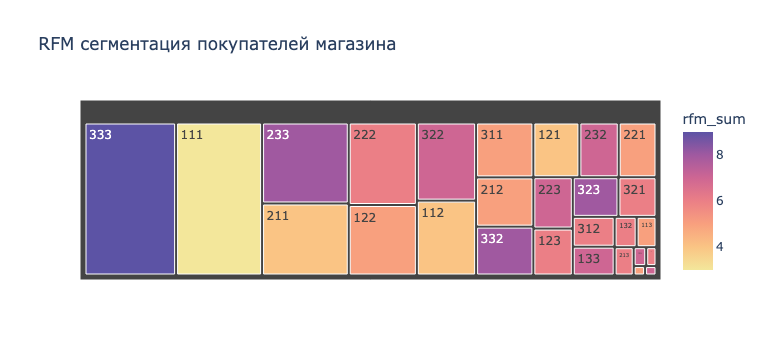

In [87]:
fig = px.treemap(rfm_group, 
                 path=['rfm_group'],  
                 values='customer_id', 
                 color='rfm_sum',
                 color_continuous_scale='Sunset',
                 title='RFM сегментация покупателей магазина')

fig.show() 

Champions (333, 323, 332) Недавно покупали, часто и много.
Что делать:
1 Предлагать VIP-сервис: бесплатная доставка по городу, персональное поздравление.
2 Дарить бонусы на день рождения клиента или близких (например, скидка на букет/подарок).
3 Просить рекомендовать магазин знакомым («приведи друга и получи скидку»).
4 Делать ранний доступ к новогодним/сезонным коллекциям.



Loyal (233, 232, 223) Покупают регулярно, но могут тратить меньше.
Что делать:
1 Ввести накопительные карты или бонусную систему («каждая 5-я покупка — скидка»).
2 Делать акции на сопутствующие товары (упаковка, открытки, мелкие сувениры).
3 Напоминать про сезонные события (8 Марта, 14 февраля, День учителя, День матери).


At Risk (131, 221, 212) Раньше тратили хорошо, но давно не возвращались.
Что делать:
1 Отправлять персональные предложения: «Мы скучаем! Скидка 20% на следующий подарок».
2 Поздравлять с праздниками и предлагать готовые наборы (корзины, сертификаты).
3 Если это корпоративные клиенты — предложить индивидуальные условия (брендированные подарки)

Lost (например 111, 112, 121) Давно не покупают, мало заказов, низкие траты.
Что делать:
1 Использовать дешёвые массовые каналы (e-mail, соцсети, листовки в районе).
2 Сосредоточиться на праздниках, когда вероятность возврата выше.
3 Если не возвращаются — минимизировать затраты на удержание.


Общая стратегия:
фокус на Champions и Loyal — удерживать их, давать эксклюзив и ценить личный контакт.
At Risk — возвращать перед ключевыми праздниками (Новый год, 8 марта, 14 февраля).
Lost — работать только массовыми акциями, без индивидуальных затрат.

Customer Segmentation & Actions

Champions (333, 323, 332)
Recent, frequent, and high-spending customers.
Recommended actions:

Offer VIP services (free city delivery, personalized greetings).

Provide birthday bonuses for the customer or their close ones (e.g., discounts on bouquets or gifts).

Encourage referrals through “bring a friend” programs.

Grant early access to seasonal or holiday collections.

Loyal (233, 232, 223)
Regular customers with moderate spending.
Recommended actions:

Introduce loyalty cards or bonus programs (e.g., “every 5th purchase at a discount”).

Promote complementary products (gift wrapping, cards, small souvenirs).

Send reminders before seasonal events (International Women’s Day, Valentine’s Day, Teacher’s Day, Mother’s Day).

At Risk (131, 221, 212)
Previously high-value customers who have not returned recently.
Recommended actions:

Send personalized reactivation offers (e.g., “We miss you! Get 20% off your next gift”).

Offer ready-made gift sets, baskets, or certificates for holidays.

For corporate clients, propose individual conditions (e.g., branded gifts).

Lost (e.g., 111, 112, 121)
Inactive customers with few orders and low spending.
Recommended actions:

Use low-cost mass channels (email, social media, local flyers).

Focus communication around major holidays, when return probability is higher.

If reactivation fails, minimize retention costs.

Overall Strategy

The primary focus should be on Champions and Loyal customers by strengthening retention, offering exclusivity, and maintaining personal communication.
At Risk customers should be targeted ahead of key holidays (New Year, March 8, Valentine’s Day).
Lost customers should be addressed only through mass campaigns, without individual-level investment.

# 5. Проверка статистических гипотез

1 Сравните доли возвратных и невозвратных клиентов за второй и третий квартал 2019 года.

Нулевая гипотеза H₀: доли возвратных и невозвратных клиентов одинаковые за второй и третий квартал 2019 года.

Альтернатива H₁: доли различаются.

Ипользуем Z-тест — это для анализа двух групп с биномиальными исходами.

Compare the proportions of returning and non-returning customers in the second and third quarters of 2019.

Null hypothesis (H₀): There is no statistically significant difference between the proportions of returning and non-returning customers in the second and third quarters of 2019.

Alternative hypothesis (H₁): There is a statistically significant difference between the proportions of returning and non-returning customers across the two quarters.

Statistical test: A two-proportion Z-test is applied, as it is suitable for comparing proportions between two independent samples with binary outcomes.

In [88]:
mask = (df["date"] >= "2019-04-01") & (df["date"] <= "2019-06-30")
df_q2 = df[mask].copy()

In [89]:
mask = (df["date"] >= "2019-07-01") & (df["date"] <= "2019-09-30")
df_q3 = df[mask].copy()

In [90]:
orders = (
    df_q2.groupby(["order_id", "customer_id"], as_index=False)
          .agg(order_sum=("total_price","sum"), 
               order_date=("entry_date","min"))
)

orders = orders.sort_values(["customer_id", "order_date"])

first_orders = orders.groupby("customer_id").first().reset_index()

print(first_orders["order_id"].count())

2007


In [91]:
orders = (
    df_q2.groupby(["order_id", "customer_id"], as_index=False)
          .agg(order_sum=("total_price","sum"), 
               order_date=("entry_date","min"))
)

orders = orders.sort_values(["customer_id", "order_date"])

second_orders = orders.groupby("customer_id").nth(1).reset_index()

print(second_orders["order_id"].count())

839


In [92]:
orders = (
    df_q3.groupby(["order_id", "customer_id"], as_index=False)
          .agg(order_sum=("total_price","sum"), 
               order_date=("entry_date","min"))
)

orders = orders.sort_values(["customer_id", "order_date"])

first_orders = orders.groupby("customer_id").first().reset_index()

print(first_orders["order_id"].count())

2152


In [93]:
orders = (
    df_q3.groupby(["order_id", "customer_id"], as_index=False)
          .agg(order_sum=("total_price","sum"), 
               order_date=("entry_date","min"))
)

orders = orders.sort_values(["customer_id", "order_date"])

second_orders = orders.groupby("customer_id").nth(1).reset_index()

print(second_orders["order_id"].count())

931


In [94]:
successes = [839, 931]
attempts = [2007, 2152]


alpha = 0.05


z_stat, p_value = proportions_ztest(count=successes, nobs=attempts, alternative='two-sided')


print(f"z-statistic: {z_stat}, p-value: {p_value}")

if p_value < alpha:
    print("Отвергаем нулевую гипотезу: существует значимая разница между долями.")
else:
    print("Не отвергаем нулевую гипотезу: значимой разницы между долями за второй и третий квартал 2019 года нет.") 


z-statistic: -0.9505383557238138, p-value: 0.3418387742752622
Не отвергаем нулевую гипотезу: значимой разницы между долями за второй и третий квартал 2019 года нет.


2 Сравните средние чеки в странах с country_id, равному 3, 6 и 24. На основе теста Манна-Уитни сделайте вывод о том, отличаются ли средние чеки в этих странах или нет.

(3 vs 6), (3 vs 24), (6 vs 24).

Нулевая гипотеза H₀: средние чеки в парах трех стран одинаковые.

Альтернатива H₁: средние чеки различаются.

2. Compare the average order values in countries with country_id equal to 3, 6, and 24. Using the Mann–Whitney U test, determine whether the average order values differ between these countries: (3 vs 6), (3 vs 24), (6 vs 24).

Null hypothesis (H₀): The average order values are equal for each pair of the three countries.

Alternative hypothesis (H₁): The average order values differ between the countries.

In [95]:
df_avg = (
    df.groupby(["customer_id","country_id"], as_index=False)
      .agg(avg_order_value=("price","mean"))
)

In [96]:
g3 = df_avg[df_avg["country_id"] == 3]["avg_order_value"]
g6 = df_avg[df_avg["country_id"] == 6]["avg_order_value"]
g24 = df_avg[df_avg["country_id"] == 24]["avg_order_value"]

In [97]:
stat, p_value = mannwhitneyu(g3, g6, alternative='two-sided')

alpha = 0.05

print("Статистика теста:", stat)
print("P-значение:", p_value) 

if p_value < alpha:
    print("Отвергаем H0: распределения (и медианы) групп различаются.")
else:
    print("Не отвергаем H0: статистически значимых различий между группами не выявлено.")

Статистика теста: 1278.0
P-значение: 0.4488330228224927
Не отвергаем H0: статистически значимых различий между группами не выявлено.


In [98]:
stat, p_value = mannwhitneyu(g3, g24, alternative='two-sided')

alpha = 0.05

print("Статистика теста:", stat)
print("P-значение:", p_value) 

if p_value < alpha:
    print("Отвергаем H0: распределения (и медианы) групп различаются.")
else:
    print("Не отвергаем H0: статистически значимых различий между группами не выявлено.")

Статистика теста: 128.0
P-значение: 0.2536056206801479
Не отвергаем H0: статистически значимых различий между группами не выявлено.


In [99]:
stat, p_value = mannwhitneyu(g6, g24, alternative='two-sided')

alpha = 0.05

print("Статистика теста:", stat)
print("P-значение:", p_value) 

if p_value < alpha:
    print("Отвергаем H0: распределения (и медианы) групп различаются.")
else:
    print("Не отвергаем H0: статистически значимых различий между группами не выявлено.")

Статистика теста: 443.0
P-значение: 0.3822200956858628
Не отвергаем H0: статистически значимых различий между группами не выявлено.


3 Моя гипотеза заключается в том, что средний чек второго заказа выше, чем первого. Следовательно, маркетинговые затраты должны быть сконцентрированы на программах лояльности, стимулирующих возврат клиентов после первой покупки.

H₀ (нулевая): средний чек первой и второй покупки одинаков.

H₁ (альтернативная): вторая покупка дороже первой.

3. Personal hypothesis: I hypothesize that the average order value of the second purchase is higher than that of the first purchase. Based on this assumption, marketing investments should be concentrated on loyalty programs that encourage customers to return after their initial purchase.

Null hypothesis (H₀): The average order values of the first and second purchases are equal.

Alternative hypothesis (H₁): The average order value of the second purchase is higher than that of the first purchase.

In [100]:
orders = (
    df.groupby(["order_id", "customer_id"], as_index=False)
      .agg(order_sum=("total_price","sum"), 
           order_date=("entry_date","min"))   
)

orders = orders.sort_values(["customer_id", "order_date"])

orders["order_number"] = orders.groupby("customer_id").cumcount() + 1

first_two = orders[orders["order_number"] <= 2]

print(first_two.head())

       order_id  customer_id  order_sum          order_date  order_number
1054       9449           -1          0 2019-01-02 10:02:00             1
1055       9450           -1          0 2019-01-02 10:04:00             2
5924      20731         1713      55918 2019-05-22 10:39:00             1
14076     39833         1713       5196 2019-10-28 09:29:00             2
694        8520         1717       7980 2019-01-23 14:58:00             1


In [101]:
first_orders = first_two[first_two["order_number"] == 1][["customer_id","order_sum"]]
first_orders = first_orders.rename(columns={"order_sum": "first_order"})

second_orders = first_two[first_two["order_number"] == 2][["customer_id","order_sum"]]
second_orders = second_orders.rename(columns={"order_sum": "second_order"})

pairs = pd.merge(first_orders, second_orders, on="customer_id", how="inner")
print(pairs.head())

   customer_id  first_order  second_order
0           -1            0             0
1         1713        55918          5196
2         1717         7980          8300
3         1718         2274          4512
4         1727         5100         10200


In [102]:
print(second_orders.head())

       customer_id  second_order
1055            -1             0
14076         1713          5196
2052          1717          8300
9504          1718          4512
10779         1727         10200


In [103]:
alpha = 0.05
results = ttest_rel(pairs["first_order"], pairs["second_order"], alternative='less')

p_value = results.pvalue / 2

print("p-значение:", p_value)

if p_value < alpha and pairs["first_order"] < pairs["second_order"].mean():
    print("Отвергаем H0: второй заказ дороже первого")
else:
    print("Не получилось отвергнуть H0: нельзя утверждать, что второй заказ дороже первого.")

p-значение: 0.49963831554585003
Не получилось отвергнуть H0: нельзя утверждать, что второй заказ дороже первого.


# 6 Отчет об анализе данных магазина «Подарочек»

На первом шаге подготовки данных я очистила их от дубликатов и пропусков, а также объединила два датасета в один (df).

При предобработке данных я удалила выбросы и аномальные показатели, которые были отражены на графиках типа «ящик с усами». Активный период продаж магазина пришёлся на 2019 год, именно этот период был взят для дальнейшего анализа.

При расчёте метрик выявлены спады и подъёмы недельной и суточной активности, отражённые на barplot-графиках. Месячный график средней выручки не показал явных колебаний или циклов, в то время как график «уникальных пользователей» продемонстрировал флуктуации. Однако сделать вывод о сезонности по одному годовому срезу невозможно.

Показатель «stickiness» за второй и третий квартал 2019 года оказался почти одинаковым — около 5%.

При визуализации RFM-анализа выявились две основные численные группы клиентов:

333 (чемпионы) — 651 человек,

233 (лояльные) — 326 человек.
Для этих сегментов можно разработать отдельные маркетинговые стратегии.

При проверке статистических гипотез:

сравнение доли возвратных и невозвратных клиентов за второй и третий квартал 2019 года не выявило значимых различий;

сравнение средних чеков в странах с country_id = 3, 6 и 24 также не выявило статистически значимых различий;

гипотеза о том, что средний чек второго заказа выше, чем первого, не подтвердилась.

Overall (общий вывод)

Анализ показал, что 2019 год был наиболее активным периодом продаж. При этом в динамике недельной и дневной активности наблюдались колебания, но сезонность по месячным данным не подтверждена. Показатель вовлечённости клиентов (stickiness) стабилен во 2-м и 3-м квартале (~5%). RFM-анализ выделил ключевые сегменты клиентов (чемпионы и лояльные), на которые стоит ориентировать маркетинговые усилия. Проверка статистических гипотез показала, что существенных различий между кварталами, странами и между первым и вторым заказом не выявлено.

Data Preparation and Exploratory Analysis

At the initial stage of data preparation, the dataset was cleaned by removing duplicates and missing values. Two source datasets were then merged into a single dataframe (df).

During preprocessing, outliers and anomalous values were removed based on boxplot visualizations. The most active sales period for the store was identified as 2019, and this period was selected for further analysis.

Metric calculations revealed declines and peaks in both weekly and daily customer activity, which were visualized using bar plots. The monthly average revenue chart did not show clear fluctuations or cyclical patterns, while the number of unique users exhibited noticeable variability. However, conclusions about seasonality cannot be drawn based on a single annual period.

The customer stickiness metric for the second and third quarters of 2019 was found to be nearly identical, at approximately 5%.

Customer Segmentation (RFM Analysis)

Visualization of the RFM analysis revealed two dominant customer segments:

333 (Champions): 651 customers

233 (Loyal): 326 customers

These segments represent the core customer base and provide a strong foundation for developing targeted marketing strategies.

Statistical Hypothesis Testing

The following hypotheses were tested:

A comparison of the proportions of returning and non-returning customers between the second and third quarters of 2019 showed no statistically significant differences.

A comparison of average order values across countries with country_id = 3, 6, and 24 did not reveal statistically significant differences.

The personal hypothesis that the average order value of the second purchase is higher than that of the first purchase was not confirmed.

Overall Conclusion

The analysis indicates that 2019 was the most active sales period for the store. While weekly and daily activity patterns showed noticeable fluctuations, no monthly seasonality was confirmed. Customer engagement, measured by the stickiness metric, remained stable in the second and third quarters (approximately 5%). RFM analysis identified key customer segments—Champions and Loyal customers—that should be the primary focus of marketing efforts. Statistical hypothesis testing did not reveal significant differences between quarters, countries, or between first and second purchases.